In [27]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
from Preprocess import preprocess_data
from sklearn.linear_model import LinearRegression
from numpy.polynomial.polynomial import polyfit 
from sklearn.utils import resample 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, known_next_slips = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
(4897, 8)
(5150, 8)


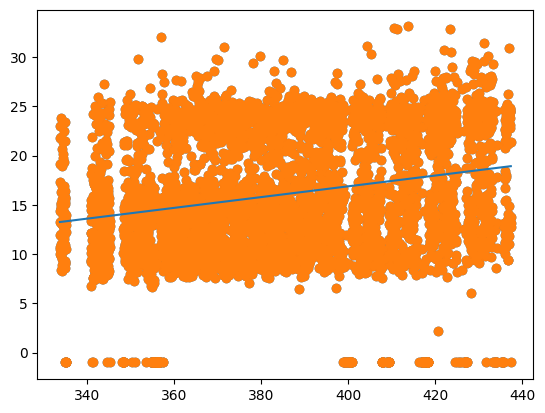

In [ ]:
'''#print(data_orig.head())
plt.figure()

x= pd.to_datetime(data_orig["start_time"]).astype(int)/(10**9 * 3600)

x=x.to_numpy()
plt.scatter(x,filtered_time["time_to_next_ev_hr"])
b, m = polyfit(x,filtered_time["time_to_next_ev_hr"],1)
plt.scatter(x,filtered_time["time_to_next_ev_hr"])
plt.plot(x, b + m * x, '-')
#plt.plot([min(X_train["TTNS"]), max(X_train["TTNS"])], [min(X_train["TTNS"]), max(X_train["TTNS"])])
#plt.xlabel("True TTNS (s)")
#plt.ylabel("Predicted TTNS (s)")
#plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()
'''

In [ ]:
X_train_bs, y_train_bs = resample(X_train, y_train, n_samples=4000, random_state=42)
X_train_bs[:20]
y_train_bs[:20]

597    90570.0
37     54525.0
285    39120.0
226    33120.0
336    42705.0
599    48585.0
597    90570.0
360    42030.0
105    33060.0
324    54435.0
251    35880.0
3      47715.0
455    77415.0
257    35235.0
70     60990.0
192    41745.0
281    27090.0
46     30780.0
423    43470.0
323    35190.0
Name: time_to_next_ev_hr, dtype: float64